# Dataset preprocess

This notebook shows how to:

- Load AIICE data
- Convert it into (X, Y) sliding windows
- Iterate with a torch DataLoader
- preprocess with inner utils

In [1]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch

In [2]:
from aiice.loader import Loader

In [3]:
loader = Loader()
data = loader.get(start="2024-01-01", end="2024-04-01", step=3, tensor_out=True)
print(data.shape)

global_series/2024/osisaf_20240110.npy:   0%|          | 0.00/747k [00:00<?, ?B/s]

global_series/2024/osisaf_20240107.npy:   0%|          | 0.00/747k [00:00<?, ?B/s]

global_series/2024/osisaf_20240104.npy:   0%|          | 0.00/747k [00:00<?, ?B/s]

global_series/2024/osisaf_20240101.npy:   0%|          | 0.00/747k [00:00<?, ?B/s]

global_series/2024/osisaf_20240116.npy:   0%|          | 0.00/747k [00:00<?, ?B/s]

...

global_series/2024/osisaf_20240331.npy:   0%|          | 0.00/747k [00:00<?, ?B/s]

global_series/2024/osisaf_20240328.npy:   0%|          | 0.00/747k [00:00<?, ?B/s]

global_series/2024/osisaf_20240325.npy:   0%|          | 0.00/747k [00:00<?, ?B/s]

global_series/2024/osisaf_20240307.npy:   0%|          | 0.00/747k [00:00<?, ?B/s]

torch.Size([31, 432, 432])


## Sliding window dataset

We wrap the 3 dimensional time-series tensor into `SlidingWindowDataset`
- `pre_history_len` — input length
- `forecast_len` — prediction length

In [4]:
from aiice.preprocess import SlidingWindowDataset

In [5]:
dataset = SlidingWindowDataset(
    data=data,
    pre_history_len=4,
    forecast_len=2,
)

print(len(dataset), dataset[0][0].shape, dataset[0][1].shape)

26 torch.Size([4, 432, 432]) torch.Size([2, 432, 432])


If `threshold` is provided:
- targets (Y) are binarized
- inputs (X) are binarized if `x_binarize=True`

In [6]:
dataset_bin = SlidingWindowDataset(
    data=data,
    pre_history_len=20,
    forecast_len=5,
    threshold=0.5,
    x_binarize=True,
)

print(dataset_bin[0][0].unique(), dataset_bin[0][1].unique())

tensor([0., 1.]) tensor([0., 1.])


You can use `SlidingWindowDataset` with pytorch `DataLoader`, which yields `(X, Y)` batches ready for training:

In [7]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

batch_x, batch_y = next(iter(dataloader))
print(batch_x.shape, batch_y.shape)

torch.Size([8, 4, 432, 432]) torch.Size([8, 2, 432, 432])


Or in a more familiar way:

In [8]:
for x, y in dataloader:
    print("batch", x.shape, y.shape)
    break

batch torch.Size([8, 4, 432, 432]) torch.Size([8, 2, 432, 432])


As you can see, the first day of our pre history is a little bit different, than the last day of our forecasting:

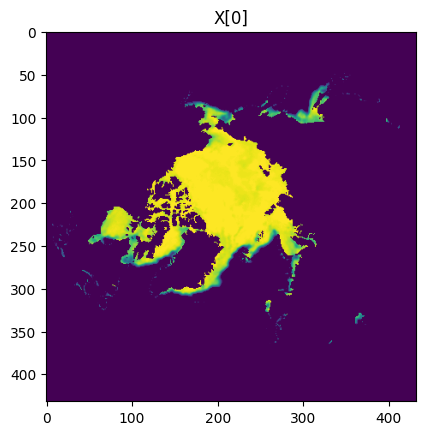

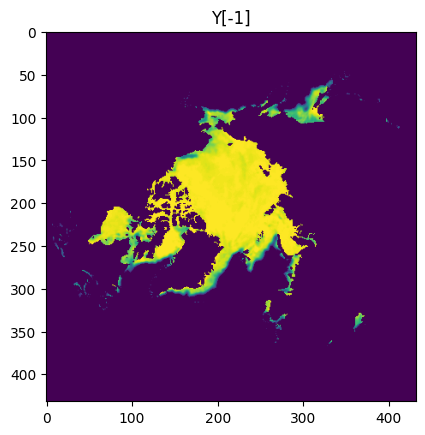

In [9]:
import matplotlib.pyplot as plt

x, y = dataset[0]

plt.figure()
plt.title("X[0]")
plt.imshow(x[0])

plt.figure()
plt.title("Y[-1]")
plt.imshow(y[-1])
plt.show()

## Preprocess

AIICE package has some internal preprocess functions, that can be used:

In [10]:
import torch

x = torch.arange(24).reshape(2,3,4)
print(x.shape, x.sum(), x.max(), x.min())

torch.Size([2, 3, 4]) tensor(276) tensor(23) tensor(0)


### `apply_threshold`

In [11]:
from aiice.preprocess import apply_threshold

In [12]:
y = apply_threshold(x, threshold=20)
print(y.shape, y.sum(), y.max(), y.min())

torch.Size([2, 3, 4]) tensor(3) tensor(1) tensor(0)


### `apply_downsample`

In [13]:
from aiice.preprocess import apply_downsample

In [14]:
y = apply_downsample(x, i=2)
print(y.shape, y.sum(), y.max(), y.min())

torch.Size([2, 3, 2]) tensor(132) tensor(22) tensor(0)
